<a href="https://colab.research.google.com/github/DienAkbar25/DesainAnalisisAlgoritma/blob/main/run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [294]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
from itertools import combinations
import time, gc, statistics, random
import tracemalloc

In [295]:
with open("data.json", "r", encoding="utf-8") as f:
    data = json.load(f)
places = {int(k): v for k, v in data["places"].items()}
day    = {int(k): int(v) for k, v in data["day"].items()}
N      = int(data["N"])

In [296]:
order_by_day = {d: sorted([n for n,t in day.items() if t==d]) for d in sorted(set(day.values()))}

linear_graph = {n: [] for n in places.keys()}
days_sorted = sorted(order_by_day.keys())
for i, d in enumerate(days_sorted):
    seq = order_by_day[d]
    for j in range(len(seq)-1):
        linear_graph[seq[j]].append((seq[j+1], 1))
    if i < len(days_sorted)-1:
        linear_graph[seq[-1]].append((order_by_day[days_sorted[i+1]][0], 1))

print("Linear adjacency list (debug):")
for u in sorted(linear_graph.keys()):
    print(f"{u:2d} -> {linear_graph[u]}")
print()

Linear adjacency list (debug):
 1 -> [(2, 1)]
 2 -> [(3, 1)]
 3 -> [(4, 1)]
 4 -> [(5, 1)]
 5 -> [(6, 1)]
 6 -> [(7, 1)]
 7 -> [(8, 1)]
 8 -> [(9, 1)]
 9 -> [(10, 1)]
10 -> [(11, 1)]
11 -> [(12, 1)]
12 -> [(13, 1)]
13 -> [(14, 1)]
14 -> [(15, 1)]
15 -> []



In [297]:
def topo_kahn(adj):

    indeg = {n: 0 for n in adj}
    # O(V) — inisialisasi indegree untuk setiap node

    for u, edges in adj.items():
        # O(V) — iterasi semua node
        for v, w in edges:
            # total seluruh edge diproses satu kali
            indeg[v] += 1
            # O(1)
    # TOTAL bagian ini: O(E)

    dq = deque([n for n in sorted(indeg.keys()) if indeg[n] == 0])
    # sorted(indeg.keys()) → O(V log V)
    # filtering indeg == 0 → O(V)
    # TOTAL: O(V log V)

    out = []
    # O(1)

    while dq:
        # setiap node masuk & keluar deque sekali → O(V)
        u = dq.popleft()
        # O(1)

        out.append(u)
        # O(1)

        for v, w in adj[u]:
            # total seluruh edge diproses satu kali
            indeg[v] -= 1
            # O(1)

            if indeg[v] == 0:
                dq.append(v)
                # O(1)
    # TOTAL while + inner loop: O(V + E)

    return out

In [298]:
def topo_dfs(adj, day_map=None):

    visited = {n: False for n in adj}
    # O(V) — inisialisasi visited untuk semua node

    stack = []
    # O(1) — inisialisasi list kosong

    def dfs(u):
        visited[u] = True
        # O(1)

        for v, w in sorted(adj.get(u, []), key=lambda x: x[0]):
        # O(d(u) log d(u)) — sorting adjacency list node u
        # jika dijumlahkan untuk semua node:
        # Σ d(u) log d(u)

            if not visited[v]:
                dfs(v)
                # O(V + E) — total traversal DFS (tiap node & edge sekali)

        stack.append(u)
        # O(1)

    if day_map is not None:
        start_nodes = sorted(adj.keys(), key=lambda x: (day_map.get(x, 0), x))
        # O(V log V) — sorting node awal berdasarkan hari + id
    else:
        start_nodes = sorted(adj.keys())
        # O(V log V)

    for n in start_nodes:
        # O(V) — loop node
        if not visited[n]:
            dfs(n)
            # DFS total sudah dihitung: O(V + E)

    stack.reverse()
    # O(V) — membalik hasil topological order

    return stack

In [299]:
def time_func(func, *args, reps=30):
    t0 = time.perf_counter()
    for _ in range(reps):
        func(*args)
    t1 = time.perf_counter()
    return (t1 - t0) / reps * 1000.0  # ms

order_kahn = topo_kahn(linear_graph)
order_dfs  = topo_dfs(linear_graph, day)

time_kahn = time_func(topo_kahn, linear_graph, reps=50)
time_dfs  = time_func(topo_dfs, linear_graph, day, reps=50)


In [300]:
def kendall_stability(a, b):
    assert set(a) == set(b)
    pos_b = {v:i for i,v in enumerate(b)}
    n = len(a)
    discord = 0
    total = 0
    for i,j in combinations(range(n), 2):
        u = a[i]; v = a[j]
        if pos_b[u] > pos_b[v]:
            discord += 1
        total += 1
    return 1.0 - (discord / total)

stability = kendall_stability(order_kahn, order_dfs)

In [301]:
def pos_per_day(order_by_day, x_step=3.0, y_step=2.0):
    pos = {}
    maxlen = max(len(v) for v in order_by_day.values())
    for i, d in enumerate(sorted(order_by_day.keys())):
        seq = order_by_day[d]
        x = i * x_step
        mid = (maxlen - 1) / 2
        for j, node in enumerate(seq):
            y = (mid - j) * y_step
            pos[node] = (x, y)
    return pos

def pos_from_order(order, x_step=1.5, y_level=0):
    pos = {}
    for i, node in enumerate(order):
        pos[node] = (i * x_step, y_level)
    return pos

def pos_day_topo(order, day_map, x_step=3.0, y_step=0.7):
    pos = {}
    rank = {n:i for i,n in enumerate(order)}
    for node in order:
        d = day_map[node]
        x = (d-1) * x_step
        y = -rank[node] * y_step
        pos[node] = (x, y)
    return pos

# build positions
pos_day = pos_per_day(order_by_day)
pos_kahn_topo = pos_from_order(order_kahn, x_step=1.2)
pos_dfs_topo  = pos_from_order(order_dfs, x_step=1.2)
pos_day_kahn_topo = pos_day_topo(order_kahn, day)
pos_day_dfs_topo = pos_day_topo(order_dfs, day)

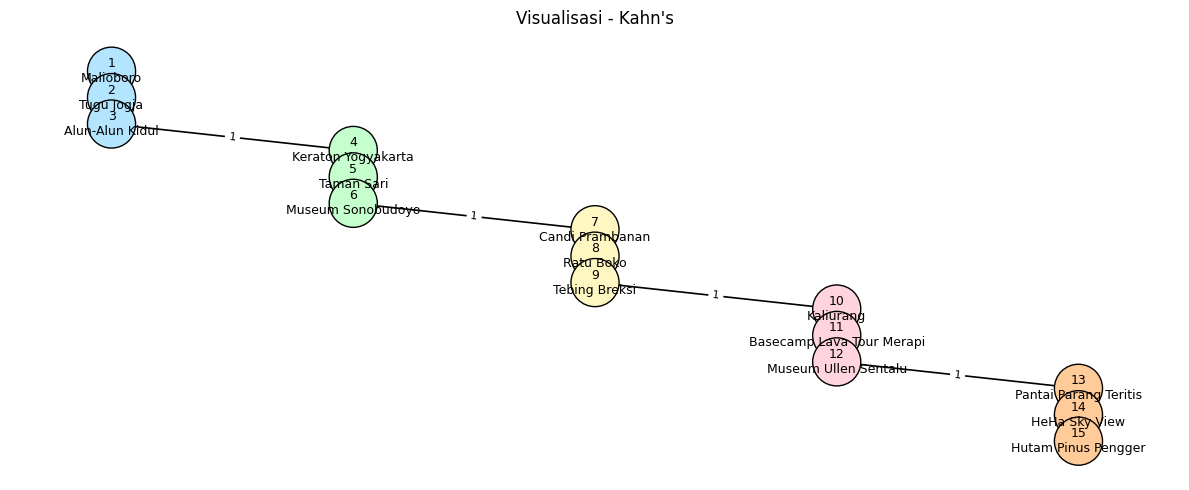

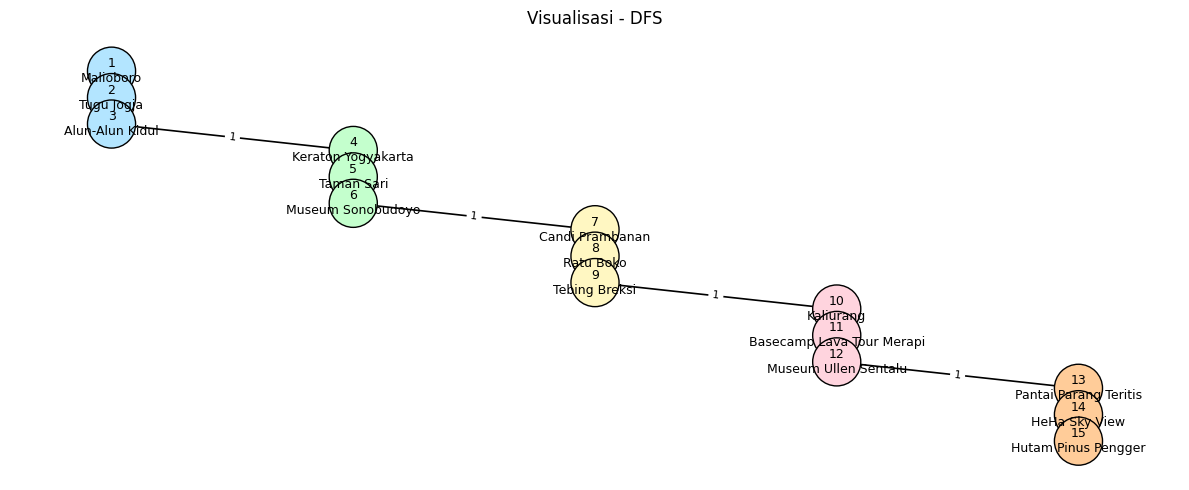

In [302]:
colors = {
    1:"#b3e5ff",
    2:"#c4ffcd",
    3:"#fff7c2",
    4:"#ffd4de",
    5:"#ffcc99"
}

def draw_graph(adj, pos, order=None, title=""):
    G = nx.DiGraph()
    for u, edges in adj.items():
        for v,w in edges:
            G.add_edge(u, v, weight=w)
    node_colors = [colors[day[n]] for n in G.nodes()]
    plt.figure(figsize=(12,5))
    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color=node_colors, edgecolors='k')
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=14, width=1.2)
    # edge labels
    edge_labels = {(u,v): G[u][v]['weight'] for u,v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    # labels: show rank if available
    if order is not None:
        rank = {n:i+1 for i,n in enumerate(order)}
        labels = {n: f"{rank[n]}\n{places[n]}" for n in G.nodes()}
    else:
        labels = {n: places[n] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_graph(linear_graph, pos_day_kahn_topo, order=order_kahn, title="Visualisasi - Kahn's")
draw_graph(linear_graph, pos_day_dfs_topo,  order=order_dfs,  title="Visualisasi - DFS")

=== GRAPH BENCHMARK (n=15) ===
Kahn  : mean=0.015668 ms  median=0.015120 ms  stdev=0.002941 ms  min=0.010770 ms  max=0.042864 ms
DFS   : mean=0.024253 ms  median=0.023443 ms  stdev=0.003178 ms  min=0.020704 ms  max=0.052329 ms



/tmp/ipython-input-1900982009.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([times_kahn, times_dfs], labels=["Kahn", "DFS"], showfliers=False)


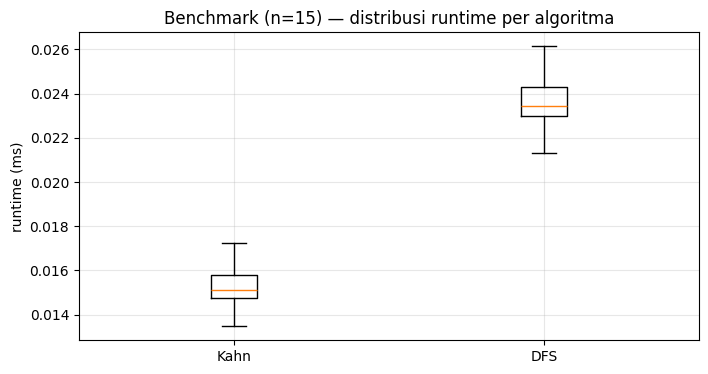

In [312]:
def bench(func, *args, reps=200):
    """Return list of runtimes in ms for `reps` runs (single-call timings)."""
    times = []
    for _ in range(20):
        func(*args)
    gc_old = gc.isenabled()
    gc.disable()
    try:
        for _ in range(reps):
            t0 = time.perf_counter()
            func(*args)
            t1 = time.perf_counter()
            times.append((t1-t0)*1000.0)
    finally:
        if gc_old:
            gc.enable()
    return times

reps = 500
times_kahn = bench(topo_kahn, linear_graph, reps=reps)
times_dfs  = bench(topo_dfs,  linear_graph, day, reps=reps)

def summarize(times):
    return {
        'n': len(times),
        'mean_ms': statistics.mean(times),
        'median_ms': statistics.median(times),
        'stdev_ms': statistics.stdev(times) if len(times)>1 else 0.0,
        'min_ms': min(times),
        'max_ms': max(times)
    }

s_k = summarize(times_kahn)
s_d = summarize(times_dfs)

print("=== GRAPH BENCHMARK (n=15) ===")
print("Kahn  : mean={mean_ms:.6f} ms  median={median_ms:.6f} ms  stdev={stdev_ms:.6f} ms  min={min_ms:.6f} ms  max={max_ms:.6f} ms".format(**s_k))
print("DFS   : mean={mean_ms:.6f} ms  median={median_ms:.6f} ms  stdev={stdev_ms:.6f} ms  min={min_ms:.6f} ms  max={max_ms:.6f} ms".format(**s_d))
print()

plt.figure(figsize=(8,4))
plt.boxplot([times_kahn, times_dfs], labels=["Kahn", "DFS"], showfliers=False)
plt.ylabel("runtime (ms)")
plt.title("Benchmark (n=15) — distribusi runtime per algoritma")
plt.grid(alpha=0.3)
plt.show()

In [304]:
def gen_layered_dag(n, layers=5):
    adj = {i: [] for i in range(1, n+1)}
    layer_size = n // layers
    for l in range(layers-1):
        for u in range(l*layer_size+1, (l+1)*layer_size+1):
            for v in range((l+1)*layer_size+1, min((l+2)*layer_size+1, n+1)):
                adj[u].append((v,1))
    return adj

In [305]:
def benchmark(func, graph, reps=300):
    times = []
    mems  = []
    gc.disable()
    for _ in range(reps):
        tracemalloc.start()
        t0 = time.perf_counter()
        func(graph)
        t1 = time.perf_counter()
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        times.append((t1 - t0) * 1000)
        mems.append(peak / 1024)
    gc.enable()
    return statistics.mean(times), statistics.mean(mems)

In [318]:
results = []

for n in Ns:
    g = gen_layered_dag(n)

    t_k, m_k = benchmark(topo_kahn, g)
    t_d, m_d = benchmark(topo_dfs, g)

    gap = (t_k - t_d) / t_d * 100
    results.append((n, t_k, t_d, gap, m_k, m_d))

In [319]:
print(f"{'n':>5} | {'Kahn (ms)':>10} | {'DFS (ms)':>10} | {'Gap (%)':>8} | {'KahnMem (KB)':>13} | {'DFSMem (KB)':>13}")
print("-"*70)

for n, k, d, g, mk, md in results:
    print(f"{n:5d} | {k:10.4f} | {d:10.4f} | {g:8.2f} | {mk:13.2f} | {md:13.2f}")

    n |  Kahn (ms) |   DFS (ms) |  Gap (%) |  KahnMem (KB) |   DFSMem (KB)
----------------------------------------------------------------------
   10 |     0.0602 |     0.0591 |     1.86 |          1.22 |          1.39
   20 |     0.0866 |     0.1037 |   -16.52 |          1.55 |          1.79
   30 |     0.1248 |     0.1674 |   -25.47 |          2.14 |          2.50
   40 |     0.1733 |     0.2013 |   -13.91 |          2.20 |          2.64
   50 |     0.2246 |     0.2528 |   -11.16 |          3.36 |          3.91
   75 |     0.4573 |     0.3973 |    15.09 |          4.07 |          4.37
  100 |     0.5678 |     0.5759 |    -1.40 |          6.75 |          7.11
  200 |     1.9083 |     1.4649 |    30.26 |         13.63 |         13.87
  500 |    12.9244 |    10.6008 |    21.92 |         27.13 |         27.50


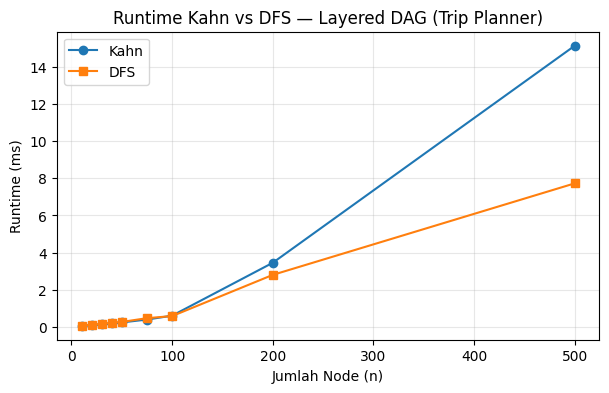

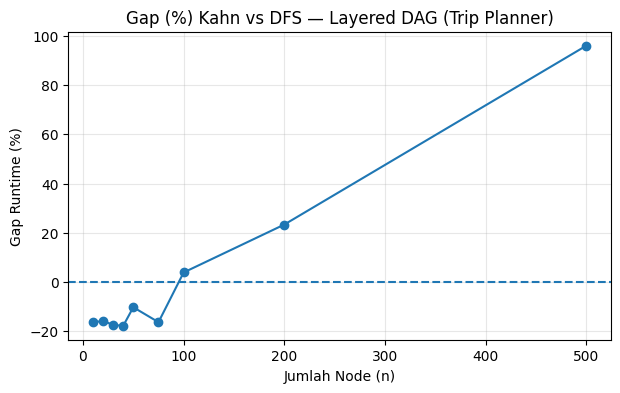

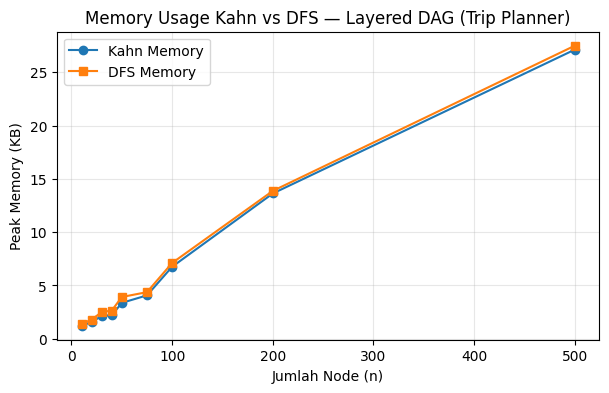

In [308]:
plt.figure(figsize=(7,4))

plt.plot(
    [x[0] for x in results],
    [x[1] for x in results],
    marker='o',
    label='Kahn'
)

plt.plot(
    [x[0] for x in results],
    [x[2] for x in results],
    marker='s',
    label='DFS'
)

plt.xlabel("Jumlah Node (n)")
plt.ylabel("Runtime (ms)")
plt.title("Runtime Kahn vs DFS — Layered DAG (Trip Planner)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(7,4))
plt.plot([x[0] for x in results],
         [x[3] for x in results],
         marker='o')

plt.axhline(0, linestyle='--')
plt.xlabel("Jumlah Node (n)")
plt.ylabel("Gap Runtime (%)")
plt.title("Gap (%) Kahn vs DFS — Layered DAG (Trip Planner)")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))

plt.plot(
    [x[0] for x in results],
    [x[4] for x in results],
    marker='o',
    label='Kahn Memory'
)

plt.plot(
    [x[0] for x in results],
    [x[5] for x in results],
    marker='s',
    label='DFS Memory'
)

plt.xlabel("Jumlah Node (n)")
plt.ylabel("Peak Memory (KB)")
plt.title("Memory Usage Kahn vs DFS — Layered DAG (Trip Planner)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [320]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   79
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                0
    BogoMIPS:                4399.99
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   